# ⚡ ENTSO-E Transparency Platform — what data can I actually get?

The [ENTSO-E Transparency Platform](https://transparency.entsoe.eu/) publishes near-real-time
electricity data for the whole European synchronous area: prices, load, generation by fuel,
cross-border flows, balancing, and outages. Its REST API exposes all of it as XML.

This notebook answers three questions:

1. **What's in the catalogue?** — every dataset the API exposes, grouped by domain.
2. **What is actually published for my bidding zone?** — coverage varies enormously by
   country and dataset, so we *probe* rather than assume, and render the result as a
   coverage matrix.
3. **What does each dataset look like?** — one worked example and one chart per domain.

We use [`entsoe-py`](https://github.com/EnergieID/entsoe-py), which wraps the raw XML API and
returns tidy pandas objects.

---

### Before you run

```bash
uv venv .venv && uv pip install --python .venv/bin/python \
    entsoe-py pandas matplotlib jupyter ipykernel python-dotenv
```

Your API key lives in `.env` as `ENTSOE_API_KEY=...`. Get one free by registering at the
Transparency Platform and emailing `transparency@entsoe.eu` to request API access.

> **Runtime note.** The coverage probe in §2 issues one request per (dataset × zone)
> cell — 84 of them — and the platform answers at roughly 7/minute, so a cold run of the
> whole notebook takes **10–20 minutes**. Every call is cached to `.entsoe_cache/`, so a
> second run is instant. Delete that directory to force a refresh, or trim `ZONES` /
> `PROBES` in §2 to make the first run shorter.

## 0 · Setup

In [1]:
import hashlib
import pickle
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import dotenv_values
from entsoe import EntsoePandasClient
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")

API_KEY = dotenv_values(".env").get("ENTSOE_API_KEY")
assert API_KEY, "Put ENTSOE_API_KEY=... in a .env file next to this notebook"
client = EntsoePandasClient(api_key=API_KEY)

# ---- what we look at -------------------------------------------------------
TZ      = "Europe/Brussels"
COUNTRY = "DE_LU"          # the bidding zone every worked example uses
DAYS    = 7                # length of the analysis window

END   = pd.Timestamp.now(tz=TZ).normalize()
START = END - pd.Timedelta(days=DAYS)

# zones compared side by side in the coverage probe (§2)
ZONES = ["DE_LU", "FR", "ES", "NL", "SE_3", "PL"]

print(f"window   {START:%Y-%m-%d %H:%M %Z}  →  {END:%Y-%m-%d %H:%M %Z}")
print(f"zone     {COUNTRY}")

window   2026-08-31 00:00 CEST  →  2026-09-07 00:00 CEST
zone     DE_LU


### A disk cache and a "never raise" wrapper

Two thirds of the interesting API calls fail for *some* zone — the TSO simply doesn't
publish that dataset, or publishes it under a different process type. That is itself the
finding, so nothing here is allowed to raise: every call returns a `(status, payload)`
pair with status `ok` / `empty` / `error`.

In [2]:
CACHE = Path(".entsoe_cache")
CACHE.mkdir(exist_ok=True)


def call(label, fn, refresh=False):
    """Run an entsoe-py query. Never raises. Returns (status, payload).

    status: 'ok'    -> payload is a non-empty Series/DataFrame
            'empty' -> the API answered "no matching data" for this zone/window
            'error'  -> payload is the exception message
    """
    key = CACHE / (hashlib.md5(f"{label}|{START}|{END}".encode()).hexdigest() + ".pkl")
    if key.exists() and not refresh:
        return pickle.loads(key.read_bytes())
    try:
        out = fn()
        empty = out is None or (hasattr(out, "empty") and out.empty) or len(out) == 0
        res = ("empty", None) if empty else ("ok", out)
    except Exception as exc:                      # noqa: BLE001 - unavailability IS the signal
        # entsoe-py raises NoMatchingDataError with an *empty* message, so fall
        # back to the class name before touching the text.
        name = type(exc).__name__
        text = str(exc).strip()
        msg = text.splitlines()[0][:140] if text else name
        nodata = name == "NoMatchingDataError" or "No matching data" in msg
        res = ("empty", None) if nodata else ("error", msg)
    key.write_bytes(pickle.dumps(res))
    return res


def show(status, payload, label):
    """Print a one-line verdict and return the payload (or None)."""
    if status != "ok":
        print(f"⚠  {label}: {status}" + (f" — {payload}" if status == "error" else ""))
        return None
    shape = getattr(payload, "shape", (len(payload),))
    print(f"✓  {label}: {shape[0]} rows" + (f" × {shape[1]} cols" if len(shape) > 1 else ""))
    return payload

### House style for the charts

One palette for the whole notebook, applied by role rather than picked per chart.
Categorical hues are assigned **in a fixed order and never cycled** — the moment a chart
needs a 9th series, the tail folds into *Other* instead of inventing a colour.

In [3]:
# categorical slots — assigned in order, never cycled
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
          "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
OTHER  = "#898781"                                    # the "everything else" grey

# sequential ramp (single hue, light -> dark) for magnitude
SEQ = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
       "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]

# status colours — reserved, never reused as a series colour
GOOD, WARN, CRIT = "#0ca30c", "#fab219", "#d03b3b"

# chrome & ink
SURFACE, INK, INK2, MUTED, GRID, AXIS = (
    "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7")

mpl.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 120,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.size": 10,
    "text.color": INK, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "600", "axes.titlelocation": "left",
    "axes.titlepad": 12, "axes.labelsize": 9.5,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "xtick.direction": "out", "ytick.direction": "out",
    "lines.linewidth": 2.0, "lines.markersize": 5,
    "legend.frameon": False, "legend.fontsize": 9,
    "legend.labelcolor": INK2,
})


def finish(ax, title, subtitle=None, ylabel=None, grid="y"):
    """Title block + recessive chrome, applied consistently to every figure.

    grid: which axis keeps its gridlines — "y" for time series (horizontal
          rules), "x" for horizontal bars, None for neither.
    """
    ax.set_title(title, pad=22 if subtitle else 12)
    if subtitle:
        ax.text(0, 1.03, subtitle, transform=ax.transAxes,
                fontsize=9.5, color=INK2, va="bottom")
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.grid(axis="x", visible=(grid == "x"))
    ax.grid(axis="y", visible=(grid == "y"))
    return ax

---
## 1 · The catalogue

`entsoe-py` exposes 41 query methods. Grouped by domain, they map onto the articles of
EU Regulation 543/2013, which is what obliges TSOs to publish this data in the first
place. The table below is the map — the *coverage probe* in the next section is the
territory.

In [4]:
CATALOGUE = [
    # domain,        method,                                     article,   what you get
    ("Load",  "query_load",                                  "6.1.A",  "Actual total load, 15/30/60 min"),
    ("Load",  "query_load_forecast",                         "6.1.B–E","Day/week/month/year-ahead load forecast"),
    ("Load",  "query_load_and_forecast",                     "6.1.A+B","Actual and day-ahead forecast, aligned"),

    ("Prices","query_day_ahead_prices",                      "12.1.D", "Day-ahead auction clearing price, €/MWh"),
    ("Prices","query_intraday_prices",                       "12.1.D", "Intraday auction prices (per sequence)"),
    ("Prices","query_imbalance_prices",                      "17.1.F–G","Imbalance settlement prices"),
    ("Prices","query_activated_balancing_energy_prices",     "17.1.F", "Prices of activated balancing energy"),
    ("Prices","query_contracted_reserve_prices",             "17.1.E", "Balancing capacity procurement prices"),

    ("Generation","query_generation",                        "16.1.B–C","Actual generation per production type"),
    ("Generation","query_generation_per_plant",              "16.1.A", "Actual output per generation unit"),
    ("Generation","query_generation_forecast",               "14.1.C", "Day-ahead aggregated generation forecast"),
    ("Generation","query_wind_and_solar_forecast",           "14.1.D", "Day-ahead wind & solar forecast"),
    ("Generation","query_intraday_wind_and_solar_forecast",  "14.1.D", "Intraday wind & solar forecast"),
    ("Generation","query_installed_generation_capacity",     "14.1.A", "Installed capacity per production type (yearly)"),
    ("Generation","query_installed_generation_capacity_per_unit","14.1.B","Installed capacity per unit ≥100 MW"),
    ("Generation","query_aggregate_water_reservoirs_and_hydro_storage","16.1.D","Reservoir filling rate, weekly"),

    ("Transmission","query_crossborder_flows",               "12.1.G", "Physical flows on one border"),
    ("Transmission","query_physical_crossborder_allborders", "12.1.G", "Physical flows, all borders of a zone"),
    ("Transmission","query_scheduled_exchanges",             "12.1.F", "Scheduled commercial exchanges"),
    ("Transmission","query_net_position",                    "12.1.F", "Net position of the bidding zone"),
    ("Transmission","query_net_transfer_capacity_dayahead",  "11.1.A", "Day-ahead NTC on a border"),
    ("Transmission","query_net_transfer_capacity_weekahead", "11.1.A", "Week-ahead NTC"),
    ("Transmission","query_net_transfer_capacity_monthahead","11.1.A", "Month-ahead NTC"),
    ("Transmission","query_net_transfer_capacity_yearahead", "11.1.A", "Year-ahead NTC"),
    ("Transmission","query_offered_capacity",                "12.1.A", "Capacity offered to the market"),
    ("Transmission","query_intraday_offered_capacity",       "12.1.A", "Intraday offered capacity"),

    ("Balancing","query_imbalance_volumes",                  "17.1.H", "Total imbalance volume of the LFC area"),
    ("Balancing","query_activated_balancing_energy",         "17.1.F", "Activated balancing energy (aFRR/mFRR/RR)"),
    ("Balancing","query_contracted_reserve_amount",          "17.1.B–C","Contracted balancing capacity"),
    ("Balancing","query_procured_balancing_capacity",        "17.1.C", "Procured balancing capacity"),
    ("Balancing","query_aggregated_bids",                    "17.1.C", "Aggregated balancing bids"),
    ("Balancing","query_current_balancing_state",            "12.3.A", "Real-time system imbalance state"),

    ("Outages","query_unavailability_of_generation_units",   "15.1.A–B","Planned & forced generation-unit outages"),
    ("Outages","query_unavailability_of_production_units",   "15.1.C–D","Planned & forced production-unit outages"),
    ("Outages","query_unavailability_transmission",          "10.1.A–B","Transmission-infrastructure outages"),
    ("Outages","query_unavailability_of_offshore_grid",      "10.1.C", "Offshore grid unavailability"),
    ("Outages","query_withdrawn_unavailability_of_generation_units","15.1","Withdrawn outage notices"),
]

catalogue = pd.DataFrame(CATALOGUE, columns=["domain", "method", "article", "returns"])
print(f"{len(catalogue)} documented endpoints across {catalogue.domain.nunique()} domains\n")
catalogue.groupby("domain", sort=False).size().to_frame("endpoints")

37 documented endpoints across 6 domains



,endpoints
domain,
Load,3
Prices,5
Generation,8
Transmission,10
Balancing,6
Outages,5


In [5]:
(catalogue.style
    .hide(axis="index")
    .set_properties(**{"text-align": "left", "font-size": "11px"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left"), ("font-size", "11px"),
                                     ("background", "#f0efec"), ("color", "#0b0b0b")]},
        {"selector": "td", "props": [("padding", "3px 10px")]},
    ]))

domain,method,article,returns
Load,query_load,6.1.A,"Actual total load, 15/30/60 min"
Load,query_load_forecast,6.1.B–E,Day/week/month/year-ahead load forecast
Load,query_load_and_forecast,6.1.A+B,"Actual and day-ahead forecast, aligned"
Prices,query_day_ahead_prices,12.1.D,"Day-ahead auction clearing price, €/MWh"
Prices,query_intraday_prices,12.1.D,Intraday auction prices (per sequence)
Prices,query_imbalance_prices,17.1.F–G,Imbalance settlement prices
Prices,query_activated_balancing_energy_prices,17.1.F,Prices of activated balancing energy
Prices,query_contracted_reserve_prices,17.1.E,Balancing capacity procurement prices
Generation,query_generation,16.1.B–C,Actual generation per production type
Generation,query_generation_per_plant,16.1.A,Actual output per generation unit


---
## 2 · Coverage probe — what is *actually* published

The catalogue is what the API *defines*. What any given TSO *publishes* is a different
question, and the gap is large: Spain has no aggregated balancing-capacity feed at the
zone level, Sweden splits into four bidding zones with no generation-per-plant data,
Germany publishes essentially everything.

So we ask. One request per (dataset × zone) cell, failures recorded rather than raised.

In [6]:
# (label, callable taking a zone code) — the datasets worth checking per zone
PROBES = {
    "Day-ahead price":     lambda z: client.query_day_ahead_prices(z, start=START, end=END),
    "Actual load":         lambda z: client.query_load(z, start=START, end=END),
    "Load forecast":       lambda z: client.query_load_forecast(z, start=START, end=END),
    "Generation by type":  lambda z: client.query_generation(z, start=START, end=END),
    "Generation forecast": lambda z: client.query_generation_forecast(z, start=START, end=END),
    "Wind/solar forecast": lambda z: client.query_wind_and_solar_forecast(z, start=START, end=END),
    "Installed capacity":  lambda z: client.query_installed_generation_capacity(z, start=START, end=END),
    "Generation per unit": lambda z: client.query_generation_per_plant(z, start=START, end=END),
    "Net position":        lambda z: client.query_net_position(z, start=START, end=END),
    "Physical flows":      lambda z: client.query_physical_crossborder_allborders(z, start=START, end=END, export=True),
    "Imbalance price":     lambda z: client.query_imbalance_prices(z, start=START, end=END),
    "Imbalance volume":    lambda z: client.query_imbalance_volumes(z, start=START, end=END),
    "Hydro reservoirs":    lambda z: client.query_aggregate_water_reservoirs_and_hydro_storage(z, start=START, end=END),
    "Generation outages":  lambda z: client.query_unavailability_of_generation_units(z, start=START, end=END),
}

rows = {}
for name, fn in PROBES.items():
    rows[name] = {z: call(f"probe:{name}:{z}", lambda z=z, fn=fn: fn(z))[0] for z in ZONES}
    print(f"  {name:<22} " + "  ".join(
        {"ok": "✓", "empty": "·", "error": "✗"}[rows[name][z]] + z for z in ZONES))

coverage = pd.DataFrame(rows).T[ZONES]
coverage

  Day-ahead price        ✓DE_LU  ✓FR  ✓ES  ✓NL  ✓SE_3  ✓PL
  Actual load            ✓DE_LU  ✓FR  ✓ES  ✓NL  ✓SE_3  ✓PL
  Load forecast          ✓DE_LU  ✓FR  ✓ES  ✓NL  ✓SE_3  ✓PL
  Generation by type     ✓DE_LU  ✓FR  ✓ES  ✓NL  ✓SE_3  ✓PL
  Generation forecast    ✓DE_LU  ✓FR  ✓ES  ✓NL  ✓SE_3  ✓PL
  Wind/solar forecast    ✓DE_LU  ✓FR  ✓ES  ✓NL  ✓SE_3  ✓PL
  Installed capacity     ✓DE_LU  ✓FR  ✓ES  ✓NL  ✓SE_3  ✓PL
  Generation per unit    ·DE_LU  ✓FR  ✓ES  ✓NL  ·SE_3  ✓PL
  Net position           ✓DE_LU  ✓FR  ✓ES  ✓NL  ✓SE_3  ✓PL
  Physical flows         ✓DE_LU  ✓FR  ✓ES  ✓NL  ✓SE_3  ✓PL
  Imbalance price        ·DE_LU  ✓FR  ✓ES  ✓NL  ✓SE_3  ✓PL
  Imbalance volume       ·DE_LU  ✓FR  ✓ES  ✓NL  ✓SE_3  ✓PL
  Hydro reservoirs       ·DE_LU  ·FR  ·ES  ·NL  ·SE_3  ·PL
  Generation outages     ✓DE_LU  ✓FR  ✓ES  ✓NL  ✓SE_3  ✓PL


,DE_LU,FR,ES,NL,SE_3,PL
Day-ahead price,ok,ok,ok,ok,ok,ok
Actual load,ok,ok,ok,ok,ok,ok
Load forecast,ok,ok,ok,ok,ok,ok
Generation by type,ok,ok,ok,ok,ok,ok
Generation forecast,ok,ok,ok,ok,ok,ok
Wind/solar forecast,ok,ok,ok,ok,ok,ok
Installed capacity,ok,ok,ok,ok,ok,ok
Generation per unit,empty,ok,ok,ok,empty,ok
Net position,ok,ok,ok,ok,ok,ok
Physical flows,ok,ok,ok,ok,ok,ok


### Reading the matrix

Three states, so this is a **status** encoding, not a magnitude one — categorical status
colours, each paired with a glyph so the meaning never rests on hue alone.

findfont: Failed to find font weight 600, now using 700.


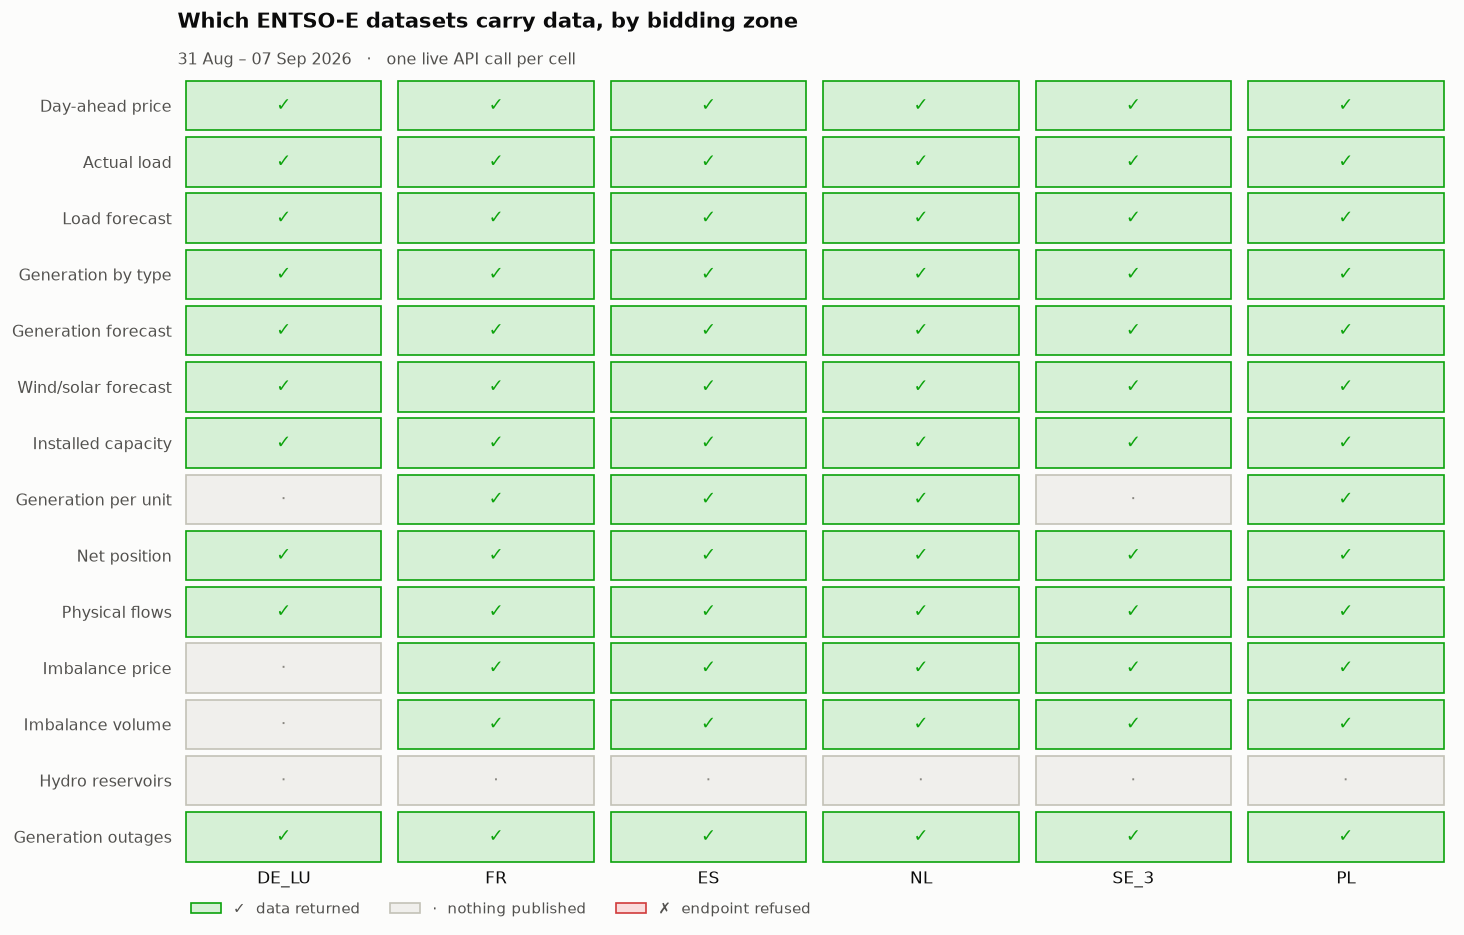


share of probed datasets returning data:
  FR      93%
  ES      93%
  PL      93%
  NL      93%
  SE_3    86%
  DE_LU   71%


In [7]:
CODE  = {"ok": 2, "empty": 1, "error": 0}
GLYPH = {"ok": "✓", "empty": "·", "error": "✗"}
FILL  = {"ok": "#d6f0d6", "empty": "#f0efec", "error": "#fadcdc"}
EDGE  = {"ok": GOOD,       "empty": AXIS,     "error": CRIT}

fig, ax = plt.subplots(figsize=(1.35 * len(ZONES) + 4.2, 0.42 * len(coverage) + 2.0))

for r, dataset in enumerate(coverage.index):
    for c, zone in enumerate(coverage.columns):
        st = coverage.loc[dataset, zone]
        # 2px surface gap between cells -> inset the patch
        ax.add_patch(plt.Rectangle((c + 0.04, r + 0.06), 0.92, 0.88,
                                   facecolor=FILL[st], edgecolor=EDGE[st], linewidth=1.0))
        ax.text(c + 0.5, r + 0.5, GLYPH[st], ha="center", va="center",
                fontsize=11, color=EDGE[st] if st != "empty" else MUTED)

ax.set_xlim(0, len(coverage.columns)); ax.set_ylim(len(coverage), 0)
ax.set_xticks(np.arange(len(coverage.columns)) + 0.5, coverage.columns, fontsize=10, color=INK)
ax.set_yticks(np.arange(len(coverage)) + 0.5, coverage.index, fontsize=9.5, color=INK2)
ax.tick_params(length=0)
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)

ax.legend(handles=[Patch(facecolor=FILL[k], edgecolor=EDGE[k], label=f"{GLYPH[k]}  {lbl}")
                   for k, lbl in [("ok", "data returned"),
                                  ("empty", "nothing published"),
                                  ("error", "endpoint refused")]],
          loc="upper left", bbox_to_anchor=(0, -0.03), ncol=3)

ax.set_title("Which ENTSO-E datasets carry data, by bidding zone",
             pad=30, fontsize=12.5)
ax.text(0, 1.012, f"{START:%d %b} – {END:%d %b %Y}   ·   one live API call per cell",
        transform=ax.transAxes, va="bottom", fontsize=9.5, color=INK2)
plt.tight_layout()
plt.show()

hit = (coverage == "ok").mean().mul(100).round(0).astype(int).sort_values(ascending=False)
print("\nshare of probed datasets returning data:")
print("\n".join(f"  {z:<6} {p:>3}%" for z, p in hit.items()))

---
## 3 · Prices — the day-ahead market

`query_day_ahead_prices` returns the single most-used series on the platform: the hourly
(now often quarter-hourly) clearing price of the day-ahead auction, in €/MWh. Negative
prices are real, not errors — they occur when must-run and subsidised generation exceeds
demand.

In [8]:
prices = show(*call(f"dap:{COUNTRY}",
                    lambda: client.query_day_ahead_prices(COUNTRY, start=START, end=END)),
              "day-ahead price")
prices.head()

✓  day-ahead price: 673 rows


2026-08-31 00:00:00+02:00    188.79
2026-08-31 00:15:00+02:00    174.97
2026-08-31 00:30:00+02:00    170.00
2026-08-31 00:45:00+02:00    166.15
2026-08-31 01:00:00+02:00    168.52
dtype: float64

findfont: Failed to find font weight 600, now using 700.


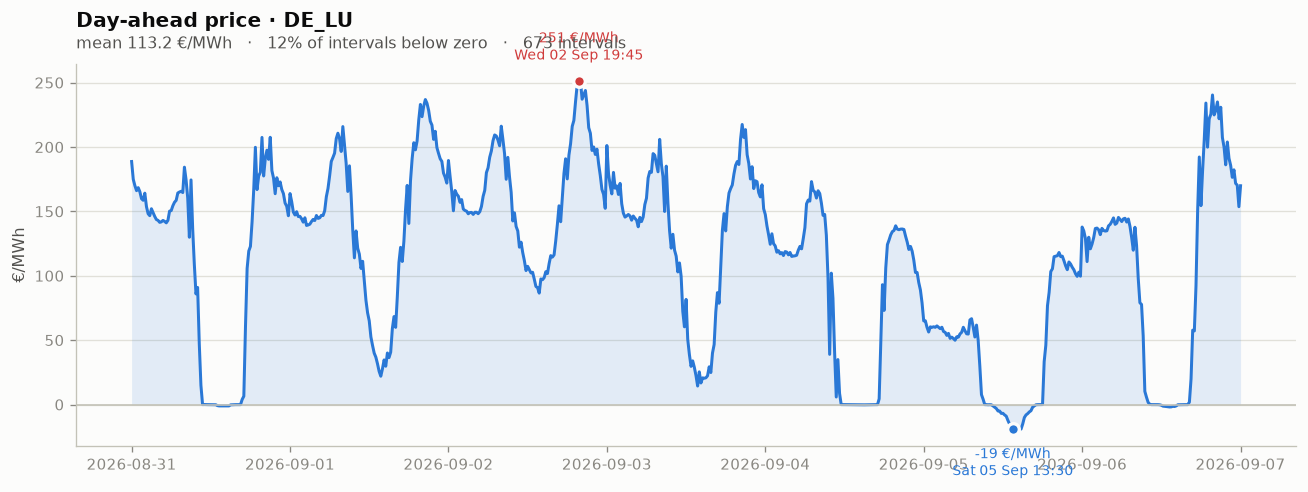

In [9]:
fig, ax = plt.subplots()
ax.plot(prices.index, prices.values, color=SERIES[0], linewidth=1.8)
ax.fill_between(prices.index, 0, prices.values, color=SERIES[0], alpha=0.12, linewidth=0)
ax.axhline(0, color=AXIS, linewidth=1.0)

lo, hi = prices.idxmin(), prices.idxmax()
for ts, va, col in [(hi, "bottom", CRIT), (lo, "top", SERIES[0])]:
    ax.plot([ts], [prices[ts]], "o", color=col, markersize=7,
            markeredgecolor=SURFACE, markeredgewidth=2, zorder=5)
    ax.annotate(f"{prices[ts]:,.0f} €/MWh\n{ts:%a %d %b %H:%M}",
                (ts, prices[ts]), textcoords="offset points",
                xytext=(0, 10 if va == "bottom" else -10),
                ha="center", va=va, fontsize=8.5, color=col)

finish(ax, f"Day-ahead price · {COUNTRY}",
       f"mean {prices.mean():,.1f} €/MWh   ·   "
       f"{(prices < 0).mean() * 100:.0f}% of intervals below zero   ·   "
       f"{len(prices)} intervals",
       "€/MWh")
plt.tight_layout(); plt.show()

The **daily shape** is the part that matters for anything storage- or flexibility-related:
averaging by hour of day collapses the week into the characteristic duck-curve profile.

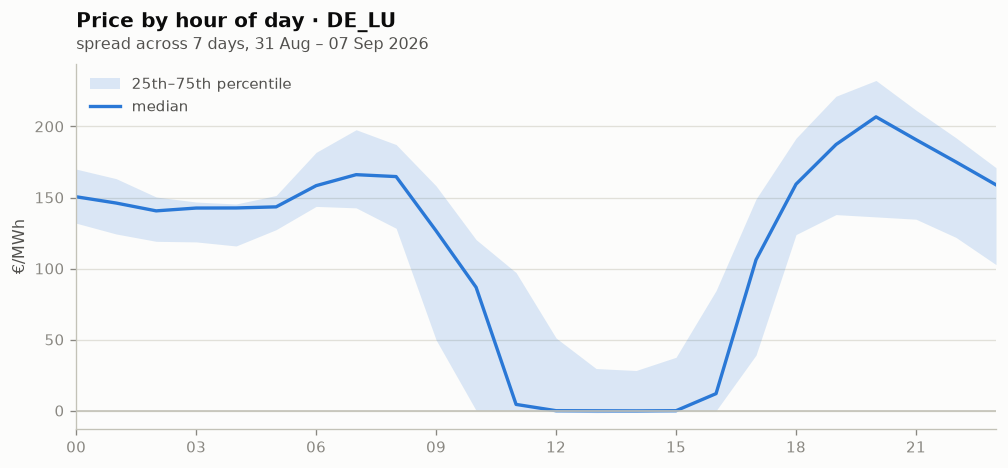

In [10]:
byhour = prices.groupby(prices.index.hour)
q25, q50, q75 = byhour.quantile(0.25), byhour.median(), byhour.quantile(0.75)

fig, ax = plt.subplots(figsize=(8.5, 4.0))
ax.fill_between(q50.index, q25, q75, color=SERIES[0], alpha=0.16, linewidth=0,
                label="25th–75th percentile")
ax.plot(q50.index, q50.values, color=SERIES[0], label="median")
ax.axhline(0, color=AXIS, linewidth=1.0)
ax.set_xticks(range(0, 24, 3), [f"{h:02d}" for h in range(0, 24, 3)])
ax.set_xlim(0, 23)
ax.legend(loc="upper left")
finish(ax, f"Price by hour of day · {COUNTRY}",
       f"spread across {DAYS} days, {START:%d %b} – {END:%d %b %Y}", "€/MWh")
plt.tight_layout(); plt.show()

---
## 4 · Load — actual vs day-ahead forecast

`query_load_and_forecast` returns both series aligned on one index, which makes TSO
forecast error directly measurable. Two quantities on the same scale and the same unit,
so they belong on one axis; the error gets its own panel rather than a second y-scale.

In [11]:
load = show(*call(f"load:{COUNTRY}",
                  lambda: client.query_load_and_forecast(COUNTRY, start=START, end=END)),
            "load & forecast")
load.head()

✓  load & forecast: 672 rows × 2 cols


,Forecasted Load,Actual Load
2026-08-31 00:00:00+02:00,40090.740634,39717.63387
2026-08-31 00:15:00+02:00,39699.744987,39553.19908
2026-08-31 00:30:00+02:00,39414.054402,39778.19418
2026-08-31 00:45:00+02:00,39327.134425,39510.63950
2026-08-31 01:00:00+02:00,38777.249060,38746.94757


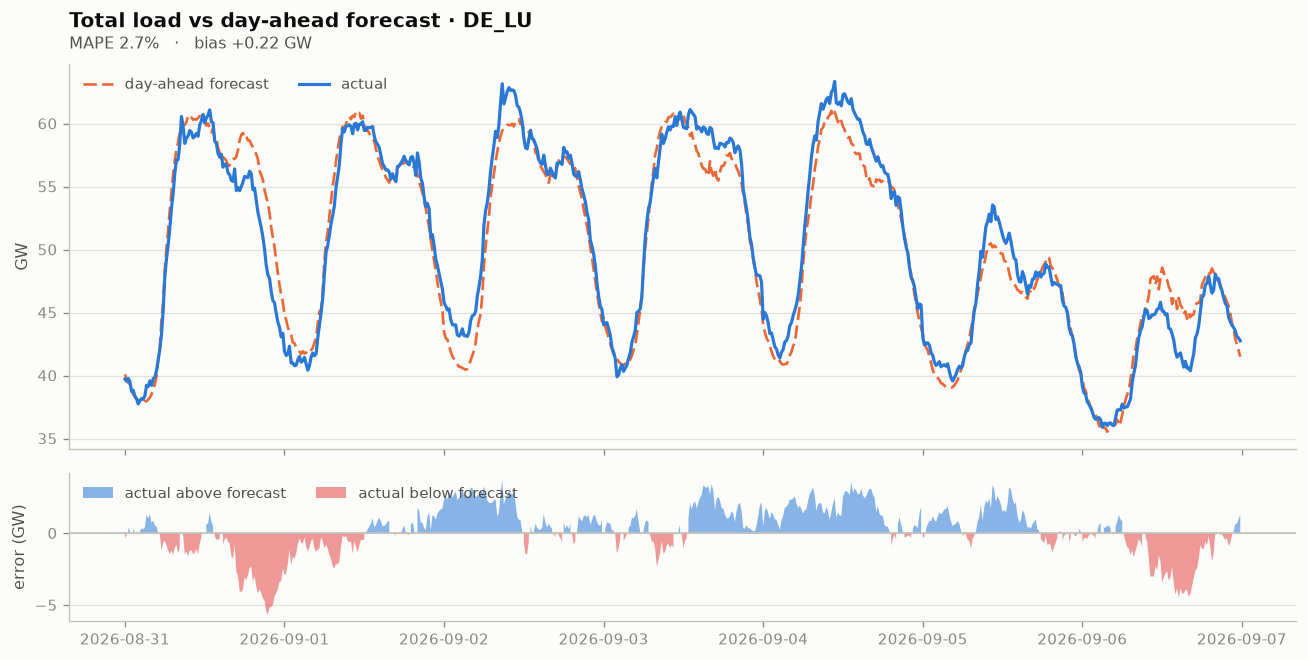

In [12]:
act, fc = load["Actual Load"].dropna(), load["Forecasted Load"].dropna()
err = (act - fc).dropna()

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True,
                              gridspec_kw={"height_ratios": [2.6, 1]})

ax.plot(fc.index, fc / 1e3, color=SERIES[1], linewidth=1.6,
        linestyle=(0, (5, 2)), label="day-ahead forecast")
ax.plot(act.index, act / 1e3, color=SERIES[0], linewidth=1.9, label="actual")
ax.legend(loc="upper left", ncol=2)
finish(ax, f"Total load vs day-ahead forecast · {COUNTRY}",
       f"MAPE {(err.abs() / act.reindex(err.index)).mean() * 100:.1f}%   ·   "
       f"bias {err.mean() / 1e3:+,.2f} GW", "GW")

ax2.axhline(0, color=AXIS, linewidth=1.0)
ax2.fill_between(err.index, 0, err / 1e3, where=err >= 0, color=SERIES[0],
                 alpha=0.55, linewidth=0, label="actual above forecast")
ax2.fill_between(err.index, 0, err / 1e3, where=err < 0, color=SERIES[7],
                 alpha=0.55, linewidth=0, label="actual below forecast")
ax2.legend(loc="upper left", ncol=2)
finish(ax2, "", None, "error (GW)")
plt.tight_layout(); plt.show()

---
## 5 · Generation mix

`query_generation` returns one column per production type (ENTSO-E "PSR type"). Zones
with pumped storage return a `MultiIndex` — a *generation* and a *consumption* column per
type — which we flatten to net generation.

There are up to 20 production types; a stacked area with 20 colours is unreadable, so the
top 7 by mean output keep a colour and the tail folds into **Other**.

In [13]:
gen = show(*call(f"gen:{COUNTRY}",
                 lambda: client.query_generation(COUNTRY, start=START, end=END)),
           "generation by type")

if isinstance(gen.columns, pd.MultiIndex):           # net = aggregated - consumption
    agg = gen.xs("Actual Aggregated", axis=1, level=1)
    con = (gen.xs("Actual Consumption", axis=1, level=1)
           if "Actual Consumption" in gen.columns.get_level_values(1) else 0)
    gen = agg.sub(con, fill_value=0)

gen = gen.dropna(how="all", axis=1).fillna(0)
print(f"{gen.shape[1]} production types reported\n")
gen.mean().sort_values(ascending=False).div(1e3).round(2).to_frame("mean GW")

✓  generation by type: 672 rows × 17 cols
16 production types reported



,mean GW
Wind Onshore,18.57
Solar,12.79
Fossil Brown coal/Lignite,5.50
Biomass,3.85
Wind Offshore,3.70
Fossil Gas,3.67
Fossil Hard coal,2.65
Hydro Run-of-river and pondage,1.06
Waste,0.74
Fossil Coal-derived gas,0.44


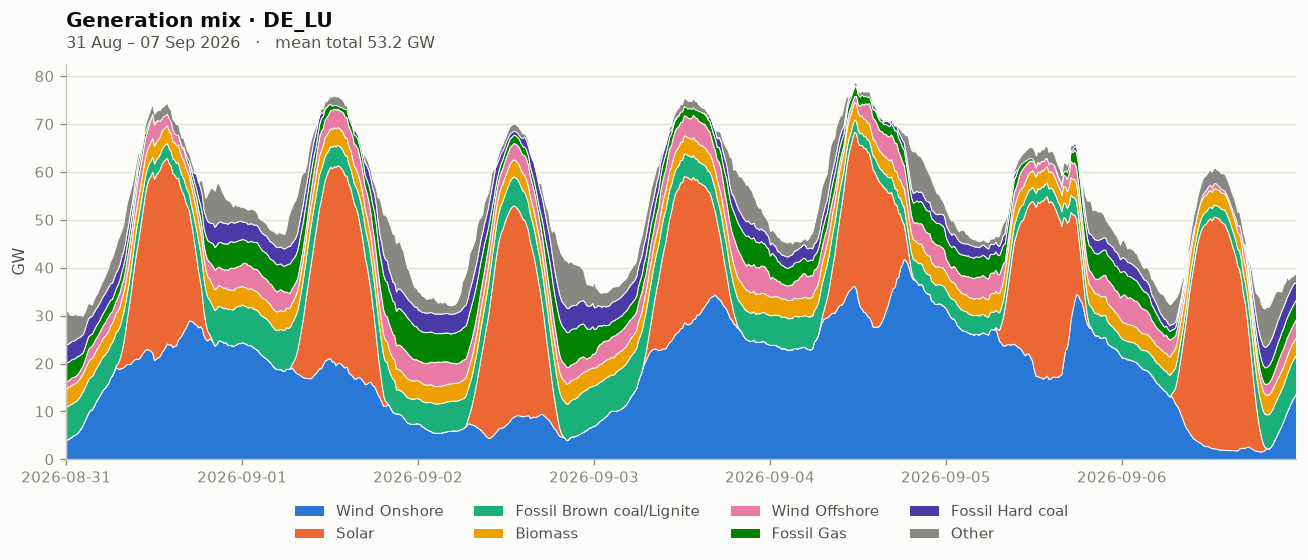

In [14]:
rank  = gen.mean().sort_values(ascending=False)
top   = list(rank.index[:7])
mix   = gen[top].copy()
if len(rank) > 7:
    mix["Other"] = gen[rank.index[7:]].sum(axis=1)

colors = SERIES[:len(top)] + ([OTHER] if len(rank) > 7 else [])

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.stackplot(mix.index, (mix.T / 1e3).values, colors=colors,
             labels=mix.columns, linewidth=0.6, edgecolor=SURFACE)  # 2px-equivalent gap
ax.set_xlim(mix.index[0], mix.index[-1])
ax.set_ylim(0, None)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=4)
finish(ax, f"Generation mix · {COUNTRY}",
       f"{START:%d %b} – {END:%d %b %Y}   ·   mean total "
       f"{mix.sum(axis=1).mean() / 1e3:,.1f} GW", "GW")
plt.tight_layout(); plt.show()

### Installed capacity vs realised output

`query_installed_generation_capacity` is a yearly snapshot in MW. Put beside the mean
output above it gives the **capacity factor** — the single number that separates
dispatchable plant from weather-driven plant.

✓  installed capacity: 1 rows × 20 cols


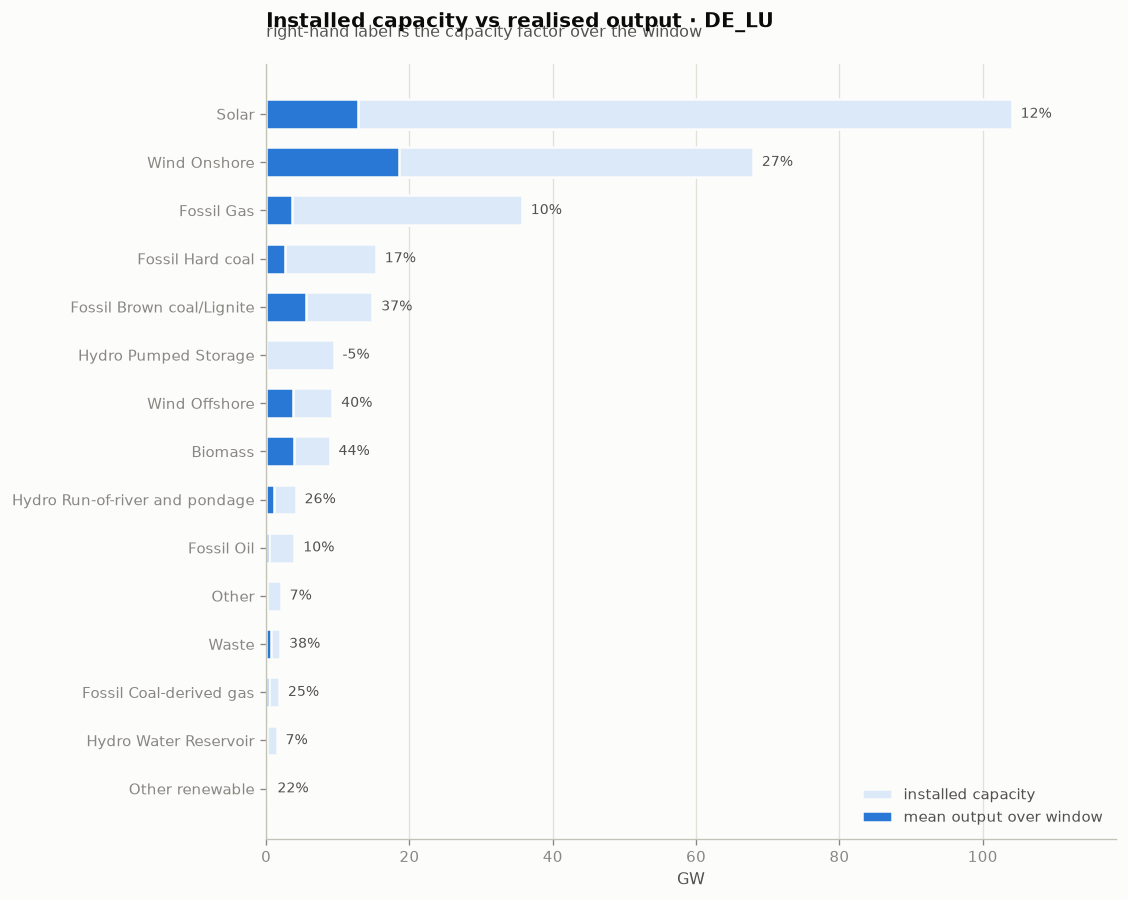

In [15]:
cap = show(*call(f"cap:{COUNTRY}",
                 lambda: client.query_installed_generation_capacity(COUNTRY, start=START, end=END)),
           "installed capacity")

cf = pd.DataFrame({"installed_GW": cap.iloc[0] / 1e3,
                   "mean_output_GW": gen.mean() / 1e3}).dropna()
cf = cf[cf.installed_GW > 0.2]
cf["capacity_factor"] = cf.mean_output_GW / cf.installed_GW
cf = cf.sort_values("installed_GW", ascending=True)

fig, ax = plt.subplots(figsize=(9.5, 0.36 * len(cf) + 2.2))
y = np.arange(len(cf))
ax.barh(y, cf.installed_GW, height=0.62, color="#dbe9f8",
        edgecolor=SURFACE, linewidth=1.5, label="installed capacity")
ax.barh(y, cf.mean_output_GW, height=0.62, color=SERIES[0],
        edgecolor=SURFACE, linewidth=1.5, label="mean output over window")

for i, (_, r) in enumerate(cf.iterrows()):
    ax.text(r.installed_GW + cf.installed_GW.max() * 0.012, i,
            f"{r.capacity_factor:.0%}", va="center", fontsize=8.5, color=INK2)

ax.set_yticks(y, cf.index, fontsize=9)
ax.set_xlim(0, cf.installed_GW.max() * 1.14)
ax.legend(loc="lower right")
finish(ax, f"Installed capacity vs realised output · {COUNTRY}",
       "right-hand label is the capacity factor over the window", None, grid="x")
ax.set_xlabel("GW")
plt.tight_layout(); plt.show()

---
## 6 · Wind & solar — forecast vs realised

The day-ahead renewables forecast (`query_wind_and_solar_forecast`, article 14.1.D) is
what the day-ahead auction actually clears against, so its error propagates straight into
intraday and balancing prices. Here it is against the realised generation from §5.

In [16]:
ws = show(*call(f"ws:{COUNTRY}",
                lambda: client.query_wind_and_solar_forecast(COUNTRY, start=START, end=END)),
          "wind & solar forecast")
ws.head()

✓  wind & solar forecast: 672 rows × 3 cols


,Solar,Wind Offshore,Wind Onshore
2026-08-31 00:00:00+02:00,0.0,1807.10,5660.98529
2026-08-31 00:15:00+02:00,0.0,1844.98,5919.38068
2026-08-31 00:30:00+02:00,0.0,1886.90,6187.58868
2026-08-31 00:45:00+02:00,0.0,1923.89,6468.83368
2026-08-31 01:00:00+02:00,0.0,1976.04,6765.30973


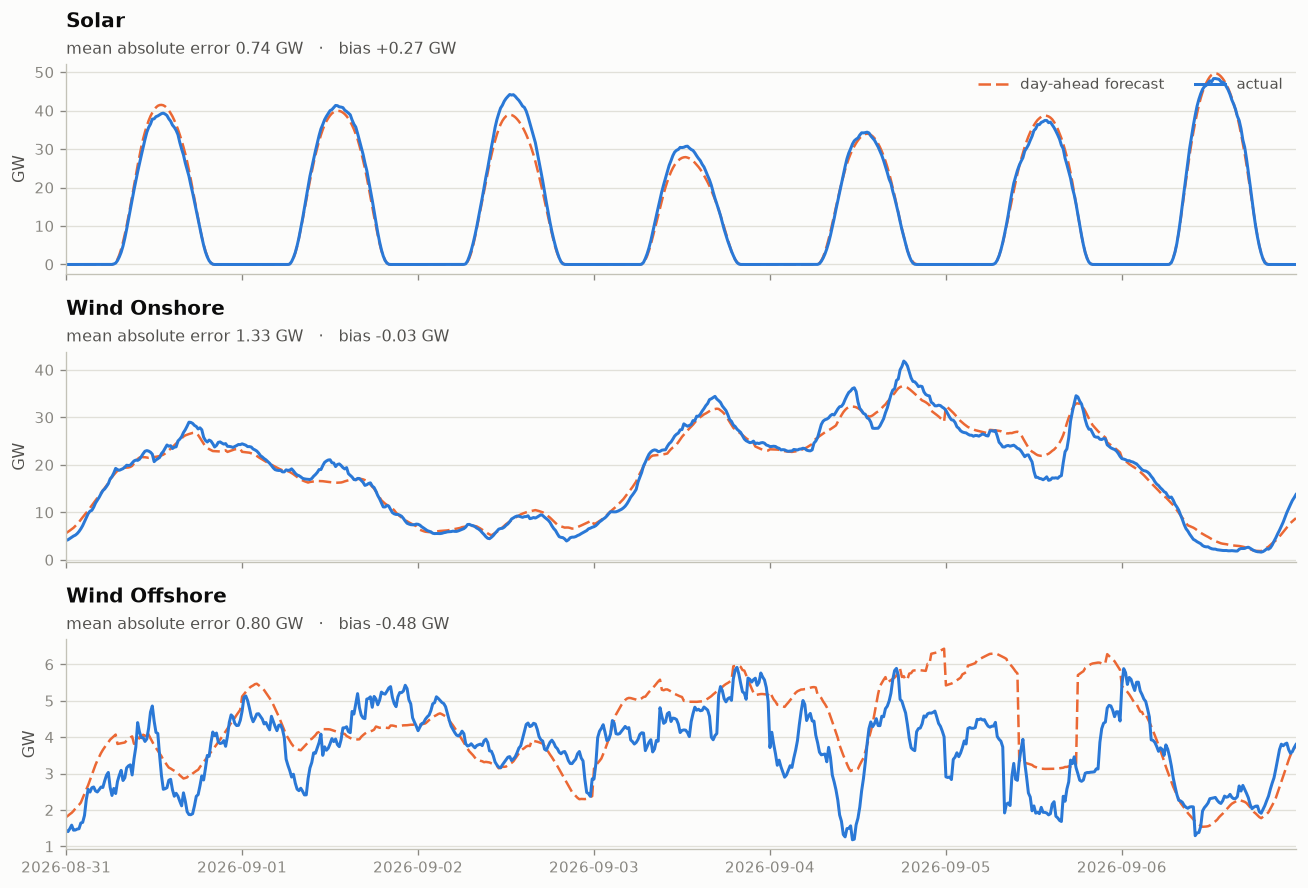

In [17]:
PAIRS = [("Solar", "Solar"),
         ("Wind Onshore", "Wind Onshore"),
         ("Wind Offshore", "Wind Offshore")]
pairs = [(f, a) for f, a in PAIRS if f in ws.columns and a in gen.columns]

fig, axes = plt.subplots(len(pairs), 1, figsize=(11, 2.5 * len(pairs)), sharex=True)
axes = np.atleast_1d(axes)

for ax, (fcol, acol) in zip(axes, pairs):
    f = ws[fcol].dropna() / 1e3
    a = gen[acol].reindex(f.index).dropna() / 1e3
    ax.plot(f.index, f.values, color=SERIES[1], linewidth=1.5,
            linestyle=(0, (5, 2)), label="day-ahead forecast")
    ax.plot(a.index, a.values, color=SERIES[0], linewidth=1.8, label="actual")
    ax.set_xlim(f.index[0], f.index[-1])
    d = (a - f.reindex(a.index)).dropna()
    finish(ax, fcol, f"mean absolute error {d.abs().mean():.2f} GW   ·   "
                     f"bias {d.mean():+.2f} GW", "GW")
    if ax is axes[0]:
        ax.legend(loc="upper right", ncol=2)

plt.tight_layout(); plt.show()

---
## 7 · Cross-border physical flows

`query_physical_crossborder_allborders` returns one column per neighbouring zone, once
for exports and once for imports. Netting the two gives signed flow per border — the
polarity here is genuine (import vs export), so this is the one place a **diverging**
encoding is correct: blue ↔ red about a neutral zero.

In [18]:
exp_ = show(*call(f"exp:{COUNTRY}",
                  lambda: client.query_physical_crossborder_allborders(
                      COUNTRY, start=START, end=END, export=True)), "exports")
imp_ = show(*call(f"imp:{COUNTRY}",
                  lambda: client.query_physical_crossborder_allborders(
                      COUNTRY, start=START, end=END, export=False)), "imports")

net = (exp_.fillna(0).sub(imp_.fillna(0), fill_value=0)
       .drop(columns=["sum"], errors="ignore"))
net.mean().sort_values().div(1e3).round(2).to_frame("mean net export GW")

✓  exports: 672 rows × 11 cols
✓  imports: 672 rows × 11 cols


,mean net export GW
FR,-0.91
NO_2,0.01
DK_2,0.11
DK_1,0.17
CH,0.25
NL,0.29
BE,0.31
PL,0.92
CZ,1.11
AT,1.31


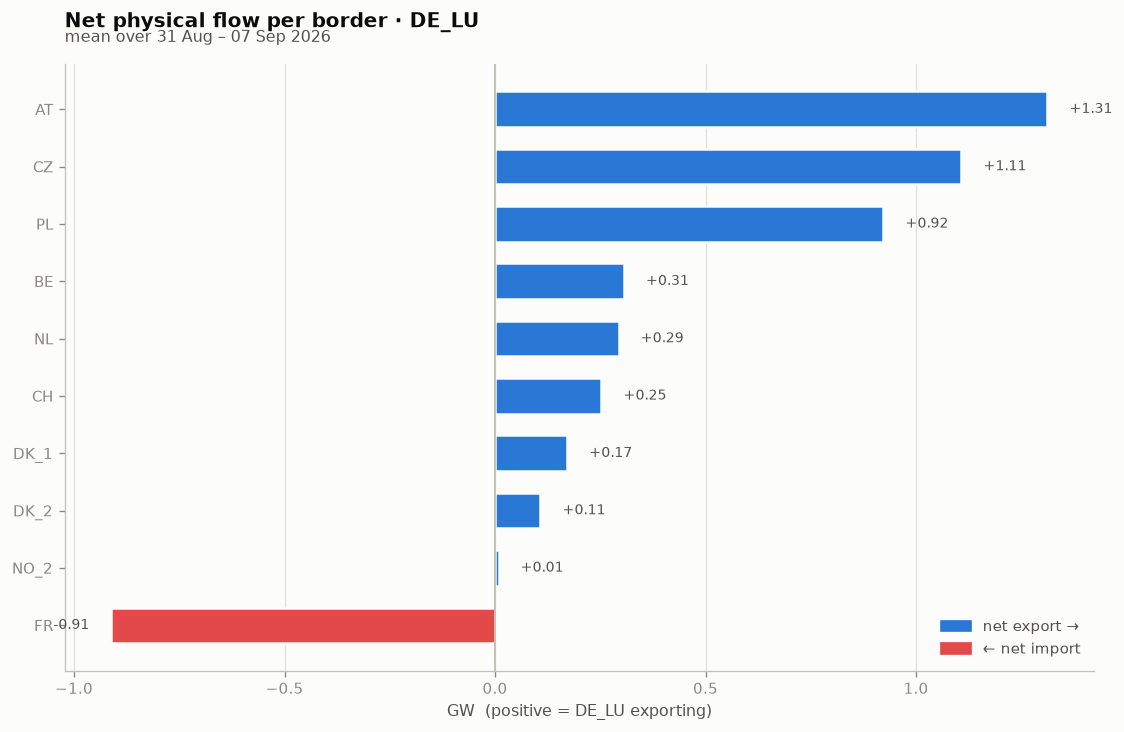

In [19]:
order = net.mean().sort_values()
vals  = order / 1e3
fig, ax = plt.subplots(figsize=(9.5, 0.4 * len(vals) + 2.2))
y = np.arange(len(vals))
ax.barh(y, vals.values, height=0.62,
        color=[SERIES[7] if v < 0 else SERIES[0] for v in vals],
        edgecolor=SURFACE, linewidth=1.5)
ax.axvline(0, color=AXIS, linewidth=1.2)
for i, v in enumerate(vals.values):
    ax.text(v + (0.02 if v >= 0 else -0.02) * abs(vals).max() * 2, i, f"{v:+.2f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=8.5, color=INK2)
ax.set_yticks(y, vals.index, fontsize=9)
ax.legend(handles=[Patch(color=SERIES[0], label="net export →"),
                   Patch(color=SERIES[7], label="← net import")],
          loc="lower right")
finish(ax, f"Net physical flow per border · {COUNTRY}",
       f"mean over {START:%d %b} – {END:%d %b %Y}", None, grid="x")
ax.set_xlabel("GW  (positive = {} exporting)".format(COUNTRY))
plt.tight_layout(); plt.show()

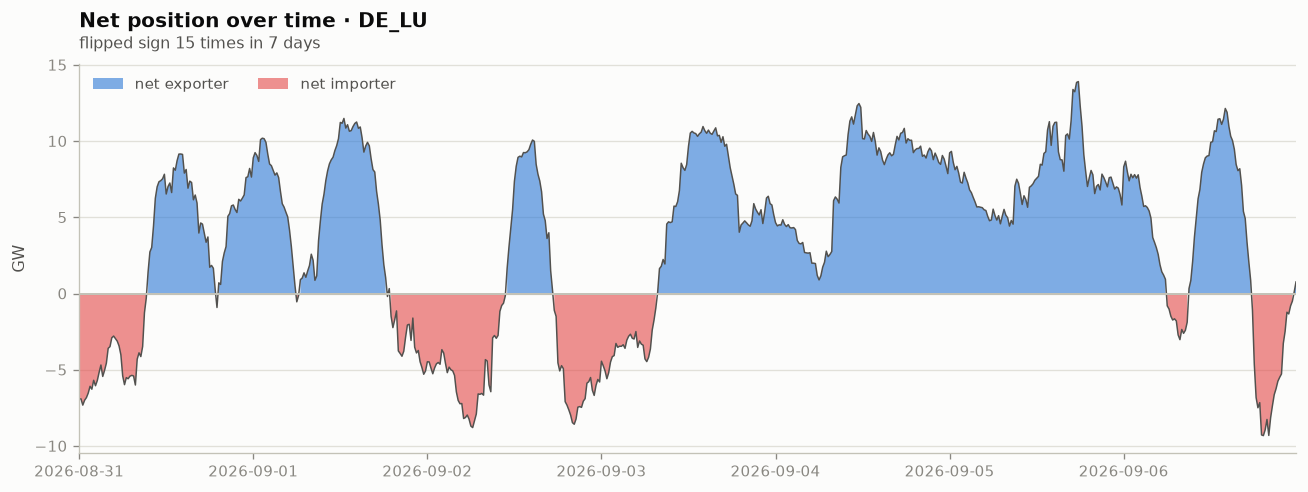

In [20]:
tot = net.sum(axis=1) / 1e3
fig, ax = plt.subplots()
ax.fill_between(tot.index, 0, tot, where=tot >= 0, color=SERIES[0], alpha=0.6,
                linewidth=0, label="net exporter")
ax.fill_between(tot.index, 0, tot, where=tot < 0, color=SERIES[7], alpha=0.6,
                linewidth=0, label="net importer")
ax.plot(tot.index, tot.values, color=INK2, linewidth=0.9)
ax.axhline(0, color=AXIS, linewidth=1.2)
ax.set_xlim(tot.index[0], tot.index[-1])
ax.legend(loc="upper left", ncol=2)
finish(ax, f"Net position over time · {COUNTRY}",
       f"flipped sign {int((np.sign(tot).diff().fillna(0) != 0).sum())} times "
       f"in {DAYS} days", "GW")
plt.tight_layout(); plt.show()

---
## 8 · Balancing & imbalance settlement

Article 17 data is the least uniformly published part of the platform — column names and
even the number of price series differ per TSO. `query_imbalance_prices` gives the price
a BRP pays (or is paid) for deviating from schedule; it is far more volatile than the
day-ahead price and is where flexibility actually earns.

In [21]:
# The coverage matrix from §2 tells us where to look: Germany publishes almost
# everything *except* article 17 imbalance data at bidding-zone level, so route
# this section to whichever probed zone actually has it.
IMB_ZONE = COUNTRY
if coverage.loc["Imbalance price", COUNTRY] != "ok":
    alt = [z for z in ZONES if coverage.loc["Imbalance price", z] == "ok"]
    if alt:
        IMB_ZONE = alt[0]
        print(f"{COUNTRY} publishes no imbalance prices — using {IMB_ZONE} instead\n")

imb = show(*call(f"imb:{IMB_ZONE}",
                 lambda: client.query_imbalance_prices(IMB_ZONE, start=START, end=END)),
           f"imbalance prices ({IMB_ZONE})")
ref = show(*call(f"dap:{IMB_ZONE}",
                 lambda: client.query_day_ahead_prices(IMB_ZONE, start=START, end=END)),
           f"day-ahead price ({IMB_ZONE})")
imb.head() if imb is not None else "not published by any probed zone"

DE_LU publishes no imbalance prices — using FR instead

✓  imbalance prices (FR): 672 rows × 2 cols
✓  day-ahead price (FR): 673 rows


,Long,Short
2026-08-31 00:00:00+02:00,143.62,159.92
2026-08-31 00:15:00+02:00,146.00,162.56
2026-08-31 00:30:00+02:00,89.57,99.73
2026-08-31 00:45:00+02:00,81.05,90.25
2026-08-31 01:00:00+02:00,103.24,114.96


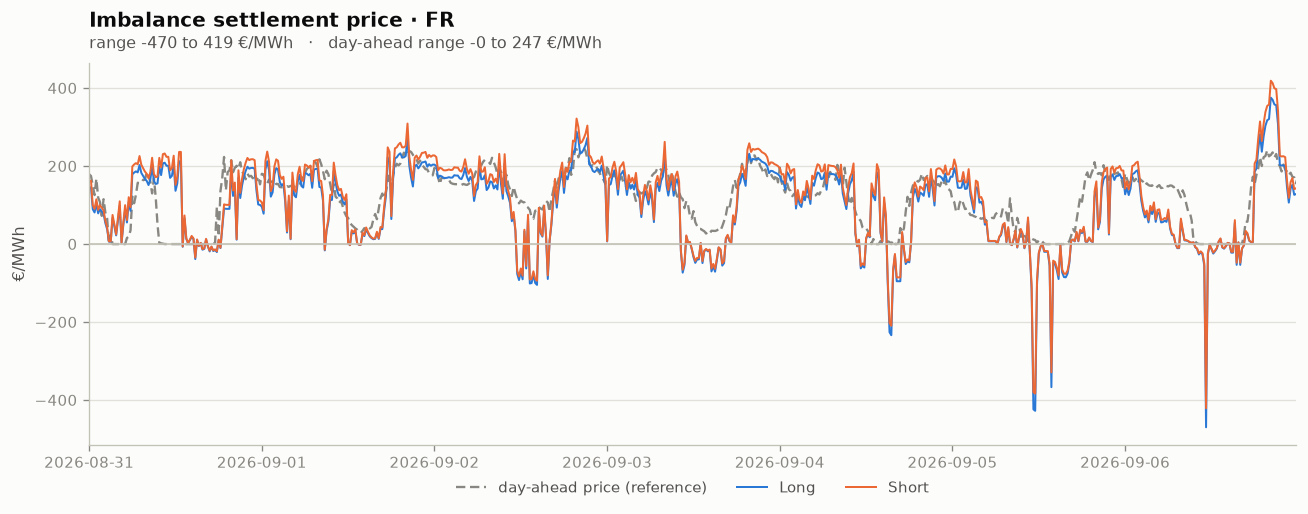

In [22]:
if imb is None:
    print("None of the probed zones published imbalance prices for this window.")
else:
    cols = [c for c in imb.columns
            if pd.api.types.is_numeric_dtype(imb[c]) and imb[c].notna().any()][:3]

    fig, ax = plt.subplots(figsize=(11, 4.4))
    if ref is not None:
        ax.plot(ref.index, ref.values, color=MUTED, linewidth=1.4,
                linestyle=(0, (4, 2)), label="day-ahead price (reference)")
    for c, col in zip(cols, SERIES):
        ax.plot(imb.index, imb[c], color=col, linewidth=1.2, label=c)
    ax.axhline(0, color=AXIS, linewidth=1.0)
    ax.set_xlim(imb.index[0], imb.index[-1])
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.06), ncol=4)

    sub = f"range {imb[cols].min().min():,.0f} to {imb[cols].max().max():,.0f} €/MWh"
    if ref is not None:
        sub += f"   ·   day-ahead range {ref.min():,.0f} to {ref.max():,.0f} €/MWh"
    finish(ax, f"Imbalance settlement price · {IMB_ZONE}", sub, "€/MWh")
    plt.tight_layout(); plt.show()

---
## 9 · Outages

The unavailability endpoints return an *event table*, not a time series: one row per
outage notice, with the affected unit, its nominal power, the available capacity during
the outage, and the business type (`A53` planned, `A54` forced). This is the only
tabular dataset in the platform and it is slow — the API ships it as a zip of XML files.

In [23]:
out = show(*call(f"outages:{COUNTRY}",
                 lambda: client.query_unavailability_of_generation_units(
                     COUNTRY, start=START, end=END)), "generation outages")

if out is not None:
    keep = [c for c in ["start", "end", "plant_type", "production_resource_name",
                        "nominal_power", "avail_qty", "businesstype"] if c in out.columns]
    o = out[keep].copy()
    o["lost_MW"] = pd.to_numeric(o.get("nominal_power"), errors="coerce") - \
                   pd.to_numeric(o.get("avail_qty"), errors="coerce")
    display(o.sort_values("lost_MW", ascending=False).head(12))

✓  generation outages: 870 rows × 18 cols


,start,end,plant_type,production_resource_name,nominal_power,avail_qty,businesstype,lost_MW
created_doc_time,,,,,,,,
2026-09-02 09:27:33+02:00,2026-09-01 20:26:00+02:00,2026-09-02 09:20:00+02:00,Fossil Brown coal/Lignite,Neurath,1058.0,0,Unplanned outage,1058.0
2026-09-07 09:02:27+02:00,2026-09-05 22:54:00+02:00,2026-09-08 12:54:00+02:00,Fossil Brown coal/Lignite,Neurath,1053.0,0,Planned maintenance,1053.0
2026-09-02 17:19:43+02:00,2026-08-13 23:29:00+02:00,2026-09-02 16:36:00+02:00,Fossil Brown coal/Lignite,Neurath,1053.0,0,Planned maintenance,1053.0
2026-09-05 16:44:37+02:00,2026-09-05 16:30:00+02:00,2026-09-05 20:00:00+02:00,Fossil Hard coal,Datteln,1052.0,0,Planned maintenance,1052.0
2026-09-07 11:16:44+02:00,2026-09-01 20:28:00+02:00,2026-09-07 10:58:00+02:00,Fossil Brown coal/Lignite,Niederaußem,927.0,0,Unplanned outage,927.0
2026-09-03 11:48:05+02:00,2026-05-22 00:00:00+02:00,2026-09-06 11:00:00+02:00,Fossil Brown coal/Lignite,KW Lippendorf,891.0,0,Planned maintenance,891.0
2026-09-04 14:42:58+02:00,2026-08-29 00:00:00+02:00,2026-09-05 04:00:00+02:00,Fossil Brown coal/Lignite,KW Lippendorf,891.0,0,Planned maintenance,891.0
2026-09-06 18:39:54+02:00,2026-05-22 00:00:00+02:00,2026-09-06 13:45:00+02:00,Fossil Brown coal/Lignite,KW Lippendorf,891.0,0,Planned maintenance,891.0
2026-09-06 23:07:51+02:00,2026-09-06 20:00:00+02:00,2026-09-06 22:00:00+02:00,Fossil Brown coal/Lignite,KW Lippendorf,891.0,0,Planned maintenance,891.0


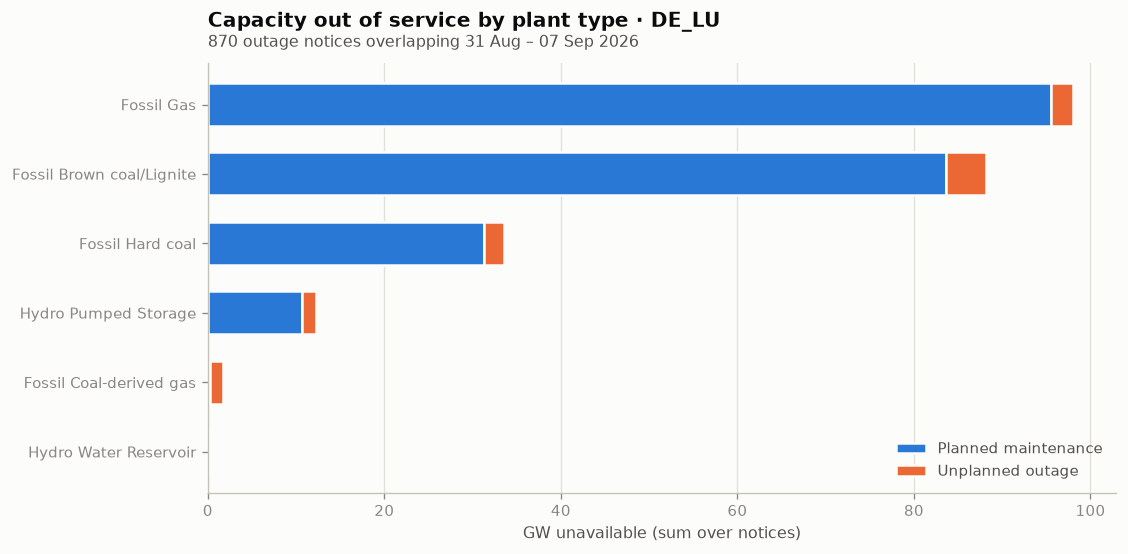

In [24]:
if out is not None and "plant_type" in out.columns:
    # entsoe-py already decodes businesstype to text ("Planned maintenance" /
    # "Unplanned outage"); fall back to the raw A-code if a TSO sends one through.
    o["kind"] = (o["businesstype"]
                 .replace({"A53": "Planned maintenance", "A54": "Unplanned outage"})
                 .fillna("Unspecified"))
    g = (o.dropna(subset=["lost_MW"])
           .groupby(["plant_type", "kind"])["lost_MW"].sum().unstack(fill_value=0) / 1e3)
    g = g.loc[g.sum(axis=1).sort_values().index]

    fig, ax = plt.subplots(figsize=(9.5, 0.42 * len(g) + 2.2))
    y, left = np.arange(len(g)), np.zeros(len(g))
    for col, c in zip(g.columns, SERIES):
        ax.barh(y, g[col], left=left, height=0.62, color=c, label=col,
                edgecolor=SURFACE, linewidth=1.5)
        left += g[col].values
    ax.set_yticks(y, g.index, fontsize=9)
    ax.legend(loc="lower right")
    finish(ax, f"Capacity out of service by plant type · {COUNTRY}",
           f"{len(o)} outage notices overlapping {START:%d %b} – {END:%d %b %Y}",
           None, grid="x")
    ax.set_xlabel("GW unavailable (sum over notices)")
    plt.tight_layout(); plt.show()

---
## 10 · Joining datasets — the merit-order signature

The point of having all of this in one place is the *join*. **Residual load**
(load minus wind and solar) is what thermal plant and imports must cover; plot the
day-ahead price against it and the merit order appears directly, as the convex curve that
steepens once cheap capacity is exhausted.

In [25]:
vre_cols = [c for c in ["Solar", "Wind Onshore", "Wind Offshore"] if c in gen.columns]
idx = act.index.intersection(gen.index).intersection(prices.index)

j = pd.DataFrame({
    "load":      act.reindex(idx),
    "vre":       gen.loc[idx, vre_cols].sum(axis=1),
    "price":     prices.reindex(idx),
}).dropna()
j["residual"] = (j.load - j.vre) / 1e3
j["hour"] = j.index.hour
print(f"{len(j)} aligned intervals; correlation price ~ residual load: "
      f"{j.residual.corr(j.price):+.2f}")
j.head()

672 aligned intervals; correlation price ~ residual load: +0.91


,load,vre,price,residual,hour
2026-08-31 00:00:00+02:00,39717.63387,5554.85195,188.79,34.162782,0
2026-08-31 00:15:00+02:00,39553.19908,5658.08277,174.97,33.895116,0
2026-08-31 00:30:00+02:00,39778.19418,5997.28277,170.00,33.780911,0
2026-08-31 00:45:00+02:00,39510.63950,6330.46390,166.15,33.180176,0
2026-08-31 01:00:00+02:00,38746.94757,6475.03801,168.52,32.271910,1


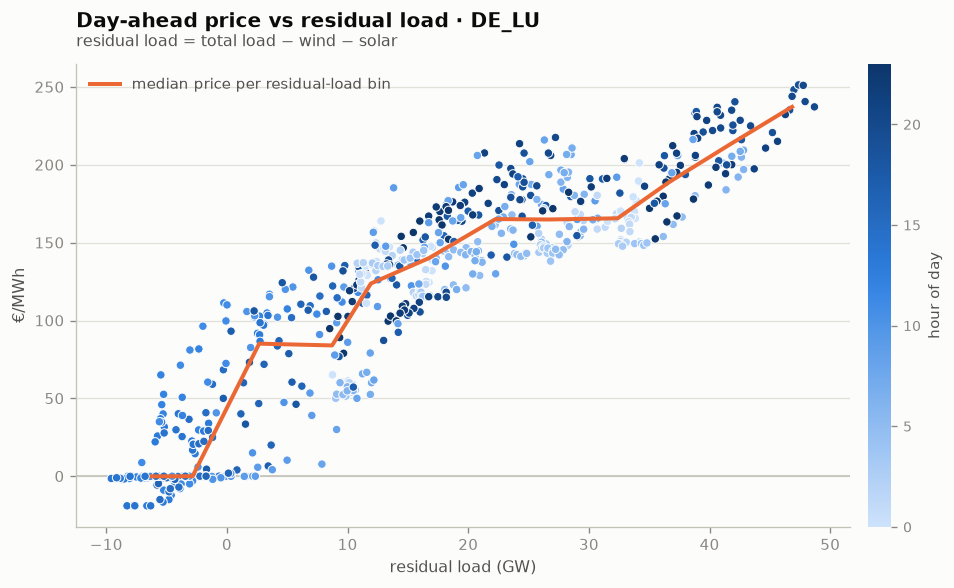

In [26]:
fig, ax = plt.subplots(figsize=(8.6, 5.0))

# sequential ramp = magnitude (hour of day), single hue, light -> dark
cmap = mpl.colors.LinearSegmentedColormap.from_list("seq", SEQ)
sc = ax.scatter(j.residual, j.price, c=j.hour, cmap=cmap, s=26,
                edgecolor=SURFACE, linewidth=0.6, zorder=3)

# binned median = the merit-order curve itself
bins = pd.cut(j.residual, 12)
curve = j.groupby(bins, observed=True).agg(x=("residual", "median"), y=("price", "median"))
ax.plot(curve.x, curve.y, color=SERIES[1], linewidth=2.4, zorder=4,
        label="median price per residual-load bin")

ax.axhline(0, color=AXIS, linewidth=1.0)
ax.legend(loc="upper left")
cb = fig.colorbar(sc, ax=ax, pad=0.02)
cb.set_label("hour of day", color=INK2, fontsize=9)
cb.outline.set_visible(False)
cb.ax.tick_params(color=MUTED, labelsize=8.5)

finish(ax, f"Day-ahead price vs residual load · {COUNTRY}",
       "residual load = total load − wind − solar", "€/MWh")
ax.set_xlabel("residual load (GW)")
plt.tight_layout(); plt.show()

---
## 11 · Reference — the codes you will need

Every ENTSO-E query is addressed by **EIC area code**; `entsoe-py` lets you pass a short
alias (`"DE_LU"`, `"SE_3"`) instead. Production types are **PSR type** codes (`B16` =
Solar). Both mapping tables ship inside the package.

In [27]:
from entsoe.mappings import Area, PSRTYPE_MAPPINGS

areas = pd.DataFrame([{"alias": a.name, "EIC code": a.value, "description": a.meaning}
                      for a in Area])
print(f"{len(areas)} areas known to entsoe-py")
areas.head(30)

100 areas known to entsoe-py


,alias,EIC code,description
0,DE_50HZ,10YDE-VE-------2,"50Hertz CA, DE(50HzT) BZA"
1,AL,10YAL-KESH-----5,"Albania, OST BZ / CA / MBA"
2,DE_AMPRION,10YDE-RWENET---I,Amprion CA
3,AT,10YAT-APG------L,"Austria, APG BZ / CA / MBA"
4,BY,10Y1001A1001A51S,Belarus BZ / CA / MBA
5,BE,10YBE----------2,"Belgium, Elia BZ / CA / MBA"
6,BA,10YBA-JPCC-----D,"Bosnia Herzegovina, NOS BiH BZ / CA / MBA"
7,BG,10YCA-BULGARIA-R,"Bulgaria, ESO BZ / CA / MBA"
8,CZ_DE_SK,10YDOM-CZ-DE-SKK,BZ CZ+DE+SK BZ / BZA
9,HR,10YHR-HEP------M,"Croatia, HOPS BZ / CA / MBA"


In [28]:
psr = (pd.Series(PSRTYPE_MAPPINGS, name="meaning")
       .rename_axis("PSR code").to_frame())
psr["kind"] = np.where(psr.index.str.startswith("B"), "production type", "asset role")
print(f"{len(psr)} codes "
      f"({(psr.kind == 'production type').sum()} of them production types)")
psr.sort_index()

28 codes (25 of them production types)


,meaning,kind
PSR code,,
A03,Mixed,asset role
A04,Generation,asset role
A05,Load,asset role
B01,Biomass,production type
B02,Fossil Brown coal/Lignite,production type
B03,Fossil Coal-derived gas,production type
B04,Fossil Gas,production type
B05,Fossil Hard coal,production type
B06,Fossil Oil,production type


### Where to go next

| If you want… | Use |
|---|---|
| a different zone | change `COUNTRY` at the top and re-run — the probe in §2 tells you which sections will have data |
| a longer history | raise `DAYS`; the API allows ~1 year per request for most endpoints, and `entsoe-py` chunks year-ahead ones automatically |
| raw XML instead of DataFrames | swap `EntsoePandasClient` for `EntsoeRawClient` |
| the full parameter reference | the [ENTSO-E API guide](https://documenter.getpostman.com/view/7009892/2s93JtP3F6) — document types, process types, business types |

**Rate limits**: 400 requests/minute per key, and the platform throttles hard above that.
The `.entsoe_cache/` directory in this notebook exists precisely so re-running costs
nothing.